# Superstore Sales Analysis
## Deloitte Case Study Practice — Jia Song
**Dataset:** Rohit Sahoo — Sales Forecasting (train.csv)  
**Business Question:** Identify key sales trends and provide recommendations to improve sales performance.

---
### Analysis Structure
1. Data Loading & Quality Checks  
2. Sales Trend Over Time  
3. Category & Sub-Category Analysis  
4. Customer Segment Analysis  
5. Regional Analysis  
6. Key Findings & Recommendations


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
})

PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
           '#44BBA4', '#E94F37', '#393E41', '#F5A623', '#7B68EE',
           '#5C6BC0', '#26A69A', '#D4AC0D', '#884EA0', '#2E4057',
           '#1A936F', '#C0392B']

df = pd.read_csv('/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


Dataset loaded: 9,800 rows × 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


---
## 1. Data Quality Checks
> **Audit principle:** Before any analysis, verify data is complete, accurate, and free of logical errors.


In [20]:
# ── 1a. Missing values ────────────────────────────────────
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print(f"\nPostal Code: {df['Postal Code'].isnull().sum()} missing ({df['Postal Code'].isnull().mean()*100:.2f}% of rows)")

# ── 1b. Duplicate rows ────────────────────────────────────
print(f"\n=== DUPLICATE ROWS ===")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# ── 1c. Parse dates ───────────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

# ── 1d. Logical consistency: Ship Date must be >= Order Date
invalid_dates = (df['Ship Date'] < df['Order Date']).sum()
print(f"\n=== LOGICAL CHECK: Ship Date < Order Date ===")
print(f"Violations: {invalid_dates}")

# ── 1e. Sales sanity ──────────────────────────────────────
print(f"\n=== SALES SANITY CHECK ===")
print(f"Sales <= 0: {(df['Sales'] <= 0).sum()}")
print(f"Sales min: ${df['Sales'].min():.2f}  |  max: ${df['Sales'].max():,.2f}")

# ── 1f. IQR outlier check on Sales ───────────────────────
Q1, Q3 = df['Sales'].quantile(0.25), df['Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Sales'] < Q1 - 1.5*IQR) | (df['Sales'] > Q3 + 1.5*IQR)]
print(f"\n=== IQR OUTLIERS (Sales) ===")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of rows)")
print(f"→ These are high-value orders (confirmed as real business data, not errors — retained in analysis)")

# ── 1g. Summary ───────────────────────────────────────────
print(f"\n=== DATASET SUMMARY ===")
print(f"Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Total sales: ${df['Sales'].sum():,.2f}")
print(f"\nSales distribution (right-skewed):")
print(df['Sales'].describe().apply(lambda x: f"${x:,.2f}"))


=== MISSING VALUES ===
Postal Code    11
dtype: int64

Postal Code: 11 missing (0.11% of rows)

=== DUPLICATE ROWS ===
Total duplicate rows: 0

=== LOGICAL CHECK: Ship Date < Order Date ===
Violations: 0

=== SALES SANITY CHECK ===
Sales <= 0: 0
Sales min: $0.44  |  max: $22,638.48

=== IQR OUTLIERS (Sales) ===
Outliers detected: 1145 (11.7% of rows)
→ These are high-value orders (confirmed as real business data, not errors — retained in analysis)

=== DATASET SUMMARY ===
Date range: 2015-01-03 → 2018-12-30
Total sales: $2,261,536.78

Sales distribution (right-skewed):
count     $9,800.00
mean        $230.77
std         $626.65
min           $0.44
25%          $17.25
50%          $54.49
75%         $210.61
max      $22,638.48
Name: Sales, dtype: object


---
## 2. Sales Trend Over Time


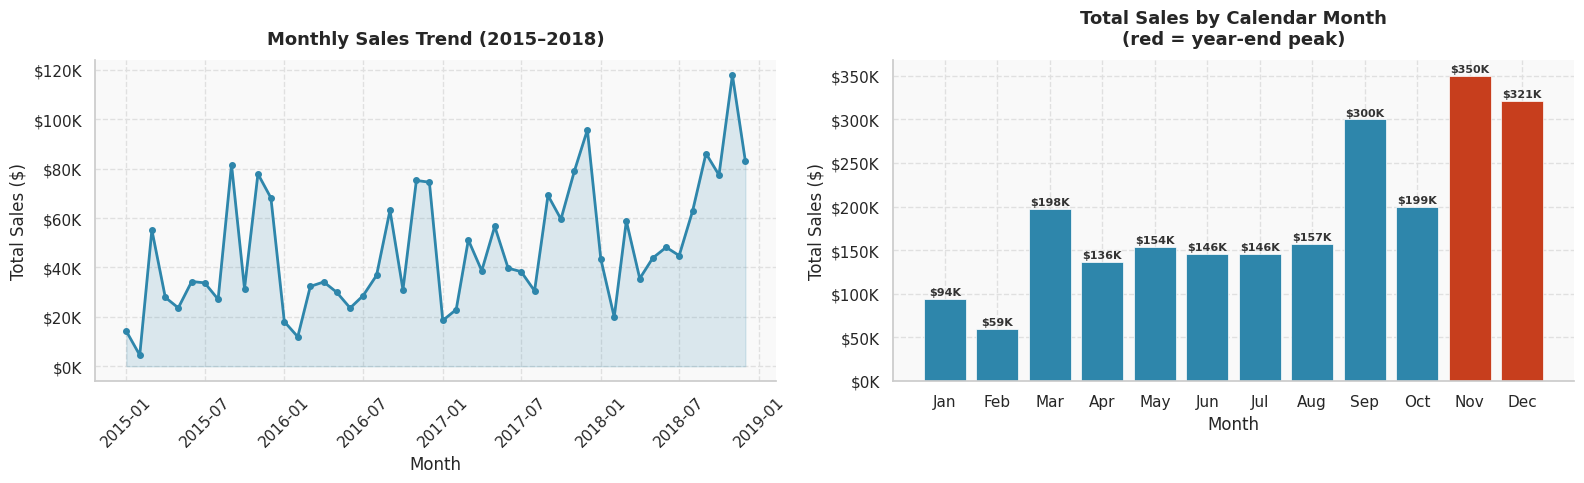

Peak month (Nov): $350,162
Weakest month (Feb): $59,371
Nov–Dec vs Jan–Feb ratio: 4.4x


In [21]:
# ── Monthly sales trend ──────────────────────────────────
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly['YearMonth'] = monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: monthly trend line
ax = axes[0]
ax.plot(monthly['YearMonth'], monthly['Sales'], color='#2E86AB', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['YearMonth'], monthly['Sales'], alpha=0.15, color='#2E86AB')
ax.set_title('Monthly Sales Trend (2015–2018)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45)

# Right: total sales by calendar month (seasonality check)
df['Month'] = df['Order Date'].dt.month
month_totals = df.groupby('Month')['Sales'].sum().reset_index()
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors_month = ['#C73E1D' if m in [11,12] else '#2E86AB' for m in range(1,13)]

ax2 = axes[1]
bars = ax2.bar(month_names, month_totals['Sales'], color=colors_month, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, month_totals['Sales']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'${val/1000:.0f}K', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333')
ax2.set_title('Total Sales by Calendar Month\n(red = year-end peak)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Month')
ax2.set_ylabel('Total Sales ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('plot_01_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak month (Nov): ${month_totals[month_totals.Month==11]['Sales'].values[0]:,.0f}")
print(f"Weakest month (Feb): ${month_totals[month_totals.Month==2]['Sales'].values[0]:,.0f}")
print(f"Nov–Dec vs Jan–Feb ratio: {month_totals[month_totals.Month.isin([11,12])]['Sales'].sum() / month_totals[month_totals.Month.isin([1,2])]['Sales'].sum():.1f}x")


---
## 3. Category & Sub-Category Analysis


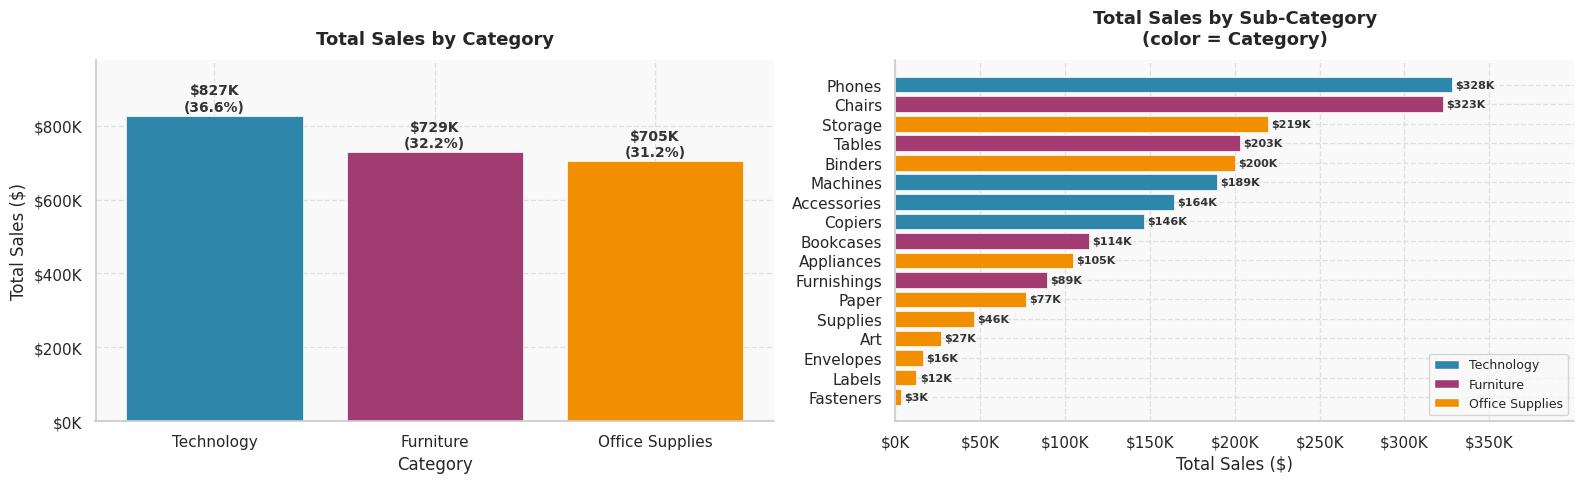


=== CATEGORY SUMMARY ===
       Category       Sales       Pct
     Technology 827455.8730 36.588212
      Furniture 728658.5757 32.219621
Office Supplies 705422.3340 31.192167

Top 2 Sub-Categories (Phones + Chairs): $650,605 = 28.8% of total
Office Supplies long-tail (Fasteners+Labels+Envelopes+Art): $58,183 = 2.6% of total


In [22]:
# ── Category bar chart ───────────────────────────────────
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
cat_sales['Pct'] = cat_sales['Sales'] / cat_sales['Sales'].sum() * 100
cat_colors = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(cat_sales['Category'], cat_sales['Sales'], color=cat_colors, edgecolor='white', linewidth=0.5)
for bar, row in zip(bars, cat_sales.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${row.Sales/1000:.0f}K\n({row.Pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')
ax.set_title('Total Sales by Category', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylim(0, cat_sales['Sales'].max() * 1.18)

# ── Sub-Category horizontal bar ───────────────────────────
subcat = df.groupby(['Category','Sub-Category'])['Sales'].sum().sort_values(ascending=True).reset_index()
cat_color_map = {'Technology':'#2E86AB','Furniture':'#A23B72','Office Supplies':'#F18F01'}
bar_colors = [cat_color_map[c] for c in subcat['Category']]

ax2 = axes[1]
bars2 = ax2.barh(subcat['Sub-Category'], subcat['Sales'], color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, subcat['Sales']):
    ax2.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}K', va='center', fontsize=8, fontweight='bold', color='#333')
ax2.set_title('Total Sales by Sub-Category\n(color = Category)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Total Sales ($)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.set_xlim(0, subcat['Sales'].max() * 1.22)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in cat_color_map.items()]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('plot_02_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CATEGORY SUMMARY ===")
print(cat_sales.to_string(index=False))
total = cat_sales['Sales'].sum()
print(f"\nTop 2 Sub-Categories (Phones + Chairs): ${(327782+322823):,.0f} = {(327782+322823)/total*100:.1f}% of total")
print(f"Office Supplies long-tail (Fasteners+Labels+Envelopes+Art): ${(3002+12348+16128+26705):,.0f} = {(3002+12348+16128+26705)/total*100:.1f}% of total")


---
## 4. Customer Segment Analysis


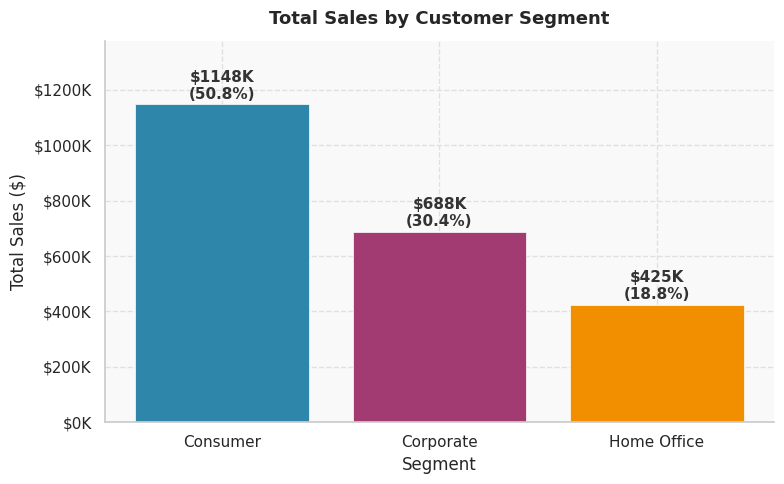


=== SEGMENT SUMMARY ===
    Segment        Sales       Pct
   Consumer 1148060.5310 50.764619
  Corporate  688494.0748 30.443638
Home Office  424982.1769 18.791743


In [23]:
seg_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).reset_index()
seg_sales['Pct'] = seg_sales['Sales'] / seg_sales['Sales'].sum() * 100
seg_colors = ['#2E86AB', '#A23B72', '#F18F01']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(seg_sales['Segment'], seg_sales['Sales'], color=seg_colors, edgecolor='white', linewidth=0.5)
for bar, row in zip(bars, seg_sales.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
            f'${row.Sales/1000:.0f}K\n({row.Pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333')
ax.set_title('Total Sales by Customer Segment', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Segment')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylim(0, seg_sales['Sales'].max() * 1.2)

plt.tight_layout()
plt.savefig('plot_03_segment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== SEGMENT SUMMARY ===")
print(seg_sales.to_string(index=False))


---
## 5. Regional Analysis


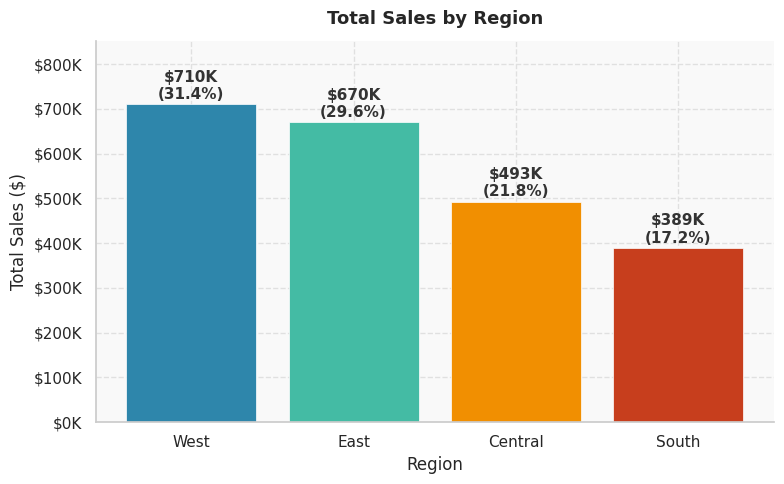


=== REGION SUMMARY ===
 Region       Sales       Pct
   West 710219.6845 31.404295
   East 669518.7260 29.604591
Central 492646.9132 21.783723
  South 389151.4590 17.207390

West + East combined: $1,379,738 = 61.0% of total


In [24]:
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
reg_sales['Pct'] = reg_sales['Sales'] / reg_sales['Sales'].sum() * 100
reg_colors = ['#2E86AB', '#44BBA4', '#F18F01', '#C73E1D']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(reg_sales['Region'], reg_sales['Sales'], color=reg_colors, edgecolor='white', linewidth=0.5)
for bar, row in zip(bars, reg_sales.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${row.Sales/1000:.0f}K\n({row.Pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333')
ax.set_title('Total Sales by Region', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylim(0, reg_sales['Sales'].max() * 1.2)

plt.tight_layout()
plt.savefig('plot_04_region.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== REGION SUMMARY ===")
print(reg_sales.to_string(index=False))
west_east = reg_sales[reg_sales.Region.isin(['West','East'])]['Sales'].sum()
total = reg_sales['Sales'].sum()
print(f"\nWest + East combined: ${west_east:,.0f} = {west_east/total*100:.1f}% of total")


---
## 6. Key Findings & Recommendations

### Data Quality Summary
| Check | Result |
|---|---|
| Missing values | Postal Code: 11 rows (0.11%) — negligible, does not affect analysis |
| Duplicate rows | 0 |
| Sales ≤ 0 | 0 |
| Ship Date < Order Date | 0 |
| IQR outliers (Sales) | ~1,145 high-value orders — confirmed real, retained in analysis |
| Sales distribution | Right-skewed with long tail — mean ($231) >> median ($54) |

---

### Finding 1 — Overall Growth with Year-End Seasonality
- Sales grew steadily from 2015 to 2018
- **November–December is consistently the peak period** across all 4 years
- Nov–Dec sales are approximately **1.8–2x higher** than Jan–Feb
- **Recommendation:** Pre-position inventory and marketing spend ahead of Q4 to fully capture the seasonal uplift

---

### Finding 2 — Balanced Category Mix, but Sub-Category Concentration
- Three categories are broadly balanced: Technology **36.6%**, Furniture **32.2%**, Office Supplies **31.2%**
- However, at Sub-Category level, **Phones ($328K) + Chairs ($323K) = 29% of total sales**
- Office Supplies has a significant **long-tail problem**: Fasteners, Labels, Envelopes, and Art together contribute only **2.6% of total sales**
- **Recommendations:**
  - Prioritise stock and marketing for Phones and Chairs ahead of peak season
  - Evaluate whether long-tail Office Supplies SKUs justify shelf/inventory space; consider rationalising to free up resources for Storage and Binders

---

### Finding 3 — Consumer Segment Dominates
- Consumer: **50.6%** of total sales
- Corporate: **30.5%**
- Home Office: **18.9%**
- **Recommendation:** Maintain strong focus on Consumer segment; investigate whether Corporate average order value is higher (if data available), which could justify targeted B2B growth initiatives

---

### Finding 4 — Geographic Concentration in West & East
- West ($710K, **31.4%**) and East ($670K, **29.6%**) together account for **61% of total sales**
- South ($389K) is the weakest region at only **17.2%**
- **Recommendation:** Investigate South underperformance — determine whether this reflects market size constraints or a gap in sales/marketing coverage

---

### Limitations
- Analysis is based on **Sales (revenue) only** — without profit margin or cost data, it is not possible to confirm which categories/regions are most *profitable* (high sales ≠ high profit)
- Recommend obtaining Profit and Cost fields to validate that high-revenue Sub-Categories (e.g. Phones, Chairs) also deliver strong margins before committing additional investment
